# Evaluate population size for bottleneck scenarios

In [1]:
from Bio import Nexus, Phylo, SeqIO
from collections import defaultdict
from io import StringIO

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import pandas as pd
import numpy as np

import re
from pathlib import Path

from itertools import combinations
from evaluation_helpers import *

In [2]:
input_csv = "../results/run_bottleneck/beast_inference/successful_mcmc_runs.csv" 
df_successful, df_failed = process_results(input_csv, population_models=['bottleneck20', "bottleneck50", "bottleneck100", "bottleneck200", "bottlenecklate", "bottlenecklatesampling", "bottleneckmid50", "bottleneckmid100"])
df_successful.head()

,population_model,mutation_signal,sampling,tree_index,tree_path_constcoal,log_path_constcoal,tree_path_skyline,log_path_skyline,sim_tree_path,present_pop_size,growth_rate,bottleneck_size,bottleneck_start,bottleneck_end
0,bottleneck100,high,independenthomochronous,0,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,1000.0,NaN,100.0,10.0,13.0
1,bottleneck100,high,independenthomochronous,1,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,1000.0,NaN,100.0,10.0,13.0
2,bottleneck100,high,independenthomochronous,2,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,1000.0,NaN,100.0,10.0,13.0
3,bottleneck100,high,independenthomochronous,3,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,1000.0,NaN,100.0,10.0,13.0
4,bottleneck100,high,independenthomochronous,4,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,/Users/mariebecker/Documents/Uni/ETH/RotationS...,1000.0,NaN,100.0,10.0,13.0


In [3]:
df_successful.groupby(['population_model', 'mutation_signal', 'sampling']).size().reset_index(name='count') 

,population_model,mutation_signal,sampling,count
0,bottleneck100,high,independenthomochronous,8
1,bottleneck100,high,linearconstant,10
2,bottleneck100,low,linearconstant,10
3,bottleneck100,med,independenthomochronous,3
4,bottleneck100,med,linearconstant,10
5,bottleneck20,high,independenthomochronous,1
6,bottleneck20,high,linearconstant,10
7,bottleneck20,low,linearconstant,10
8,bottleneck20,med,independenthomochronous,1
9,bottleneck20,med,linearconstant,10


In [4]:
df_pop_info = add_tree_information(df_successful)
df_pop_info.to_pickle("../results/run_bottleneck/evaluation/df_pop_info.pkl") 
#df_pop_info = pd.read_pickle("../results/run_bottleneck/evaluation/df_pop_info.pkl")

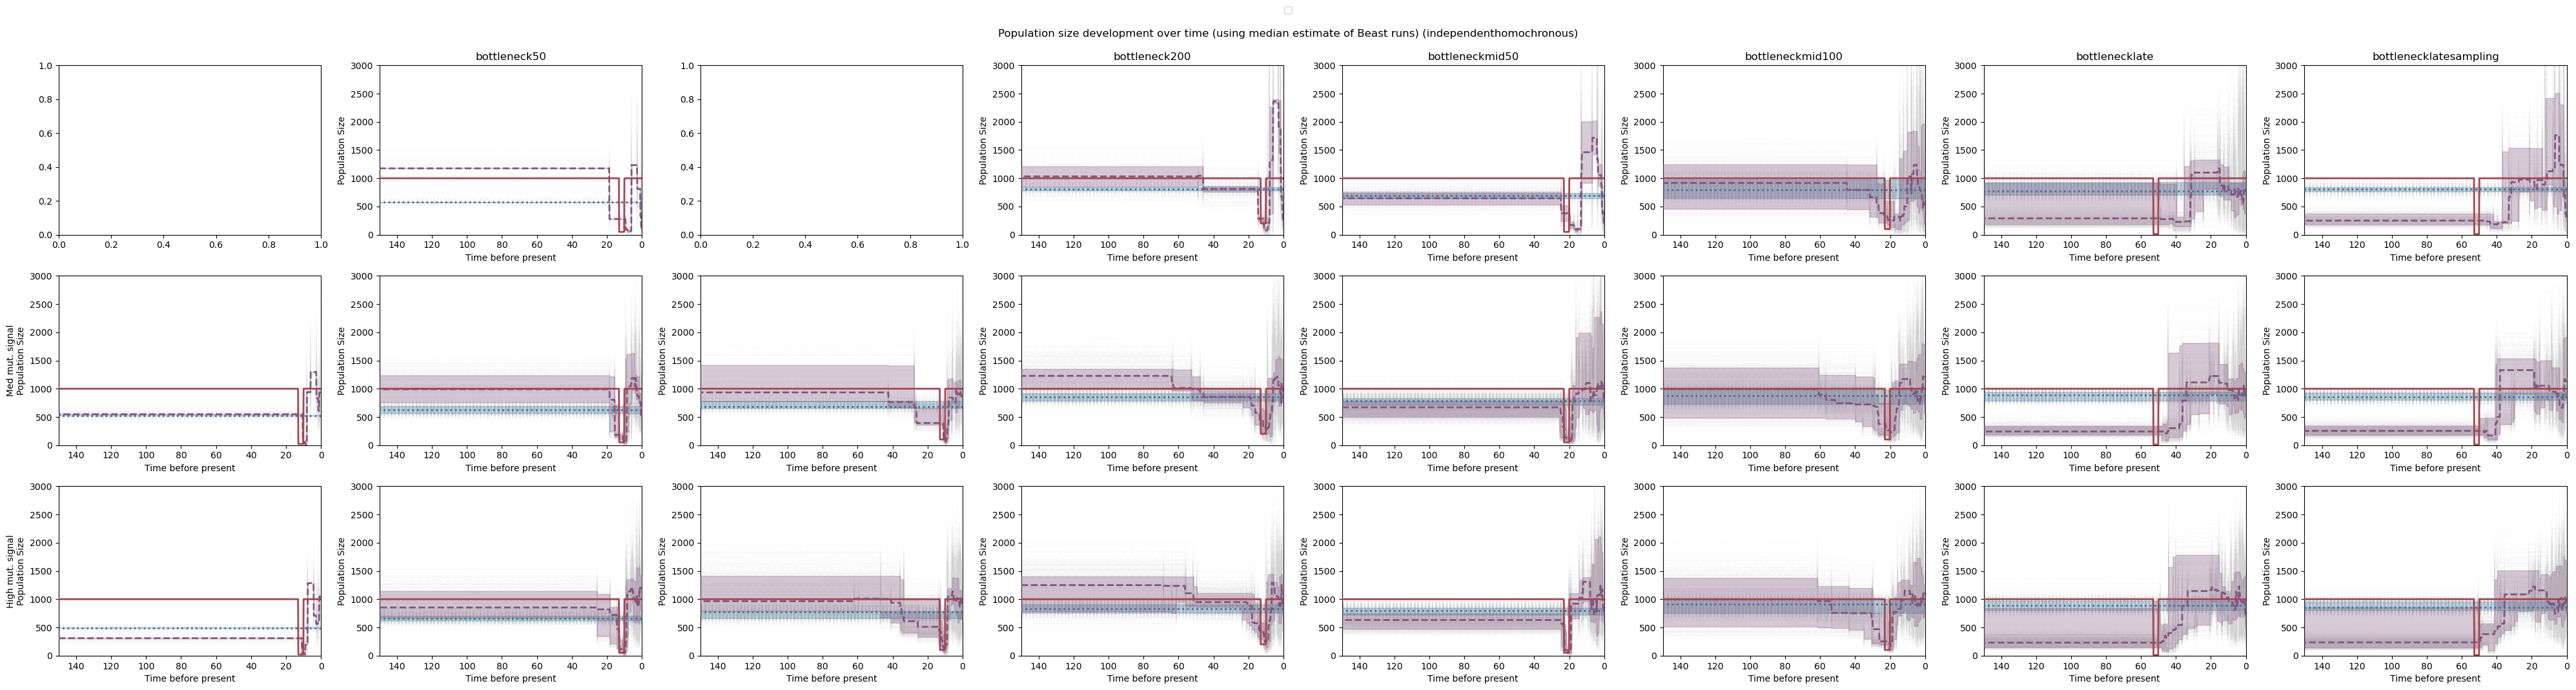

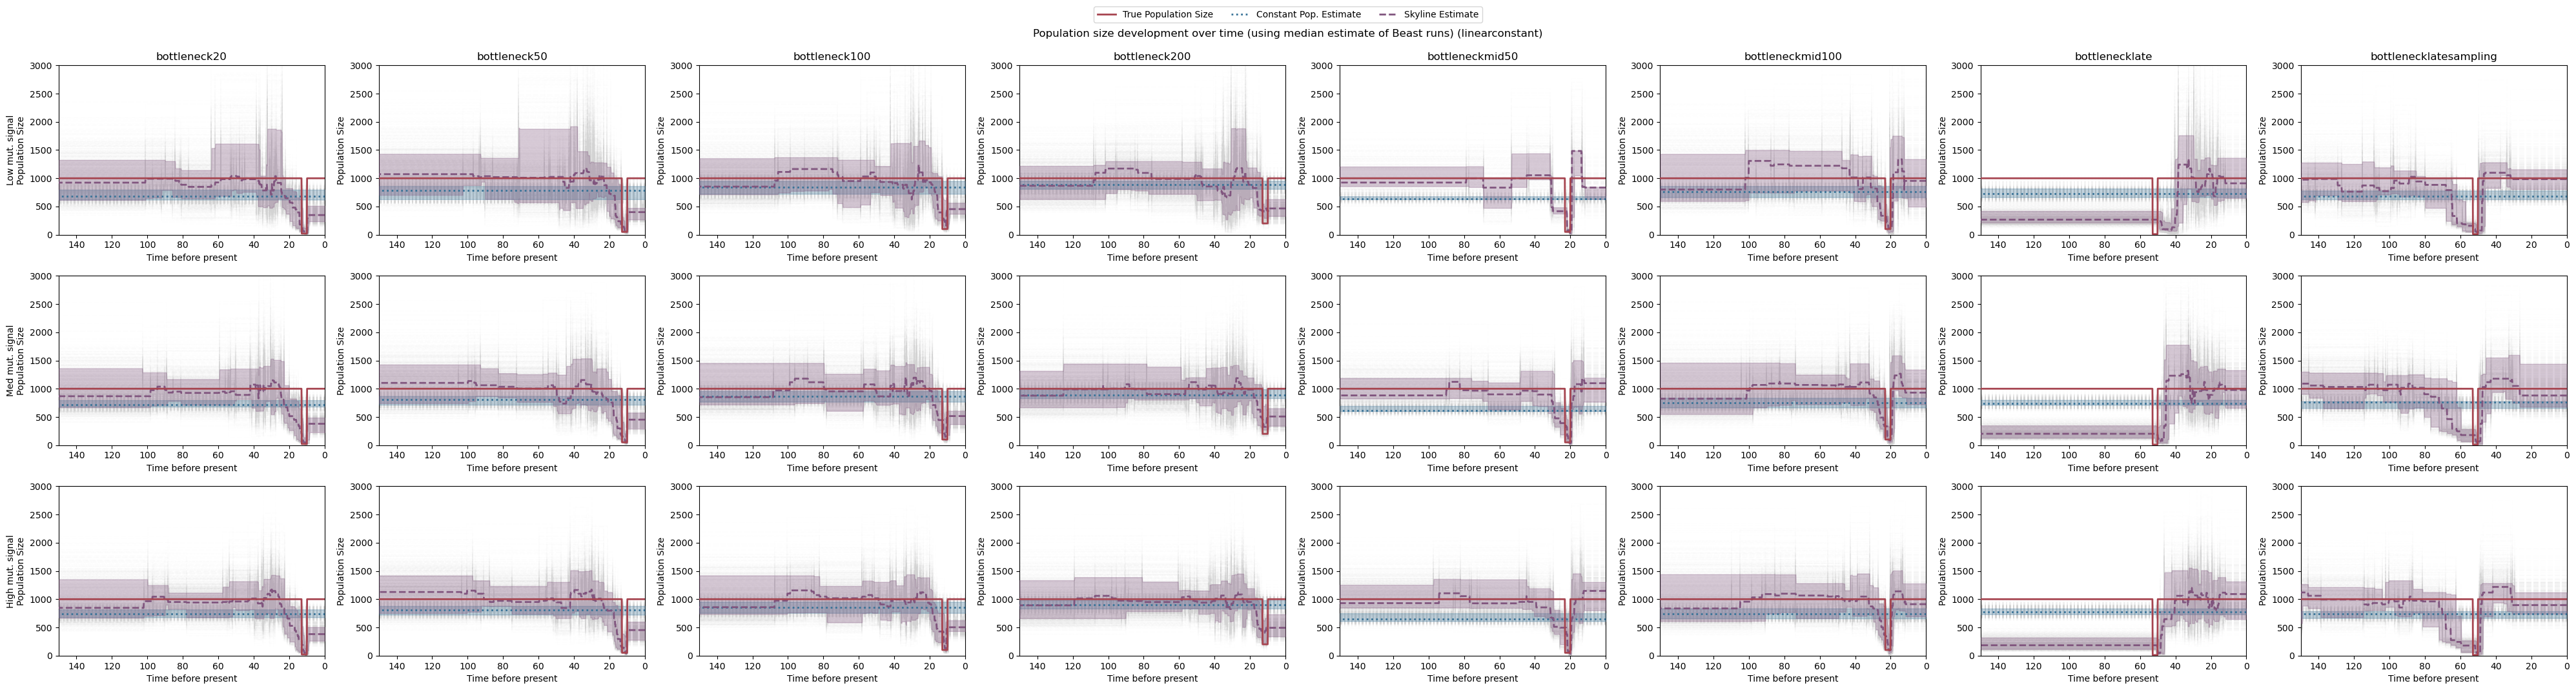

In [5]:
plot_population_summary(df_pop_info, sampling="independenthomochronous", title = 'Population size development over time (using median estimate of Beast runs)', x_range = (0,150), y_range = (0,3000), add_samples=True, mode = 'both', pop_models=['bottleneck20', "bottleneck50", "bottleneck100", "bottleneck200", "bottleneckmid50", "bottleneckmid100", "bottlenecklate", "bottlenecklatesampling"])
plot_population_summary(df_pop_info, sampling="linearconstant", title = 'Population size development over time (using median estimate of Beast runs)', x_range = (0,150), y_range = (0,3000), add_samples=True, mode = 'both', pop_models=['bottleneck20', "bottleneck50", "bottleneck100", "bottleneck200", "bottleneckmid50","bottleneckmid100", "bottlenecklate", "bottlenecklatesampling"])

In [2]:
skygrid_df = process_skygrid_logs("../results/run1/beast_inference/skygrid", burnin=0.1)
skygrid_df.head()

,sampling,population_model,mutation_signal,tree_index,cut_off,median_root_height,median_0,hpd_lower_0,hpd_upper_0,time_0,...,hpd_upper_18,time_18,median_19,hpd_lower_19,hpd_upper_19,time_19,median_20,hpd_lower_20,hpd_upper_20,time_20
0,independenthomochronous,bottleneck,high,1,100.0,1631.413229,1104.800954,846.191144,1403.407273,0.0,...,2.408111e+06,90.0,1270.420228,4.759437,208538.713392,95.0,942.950734,209.538771,3496.303483,100.0
1,independenthomochronous,bottleneck,low,0,100.0,1923.786914,1245.899038,742.115463,2070.104875,0.0,...,1.056579e+06,90.0,2602.917147,9.167989,233043.221655,95.0,2533.365833,800.198992,6936.544755,100.0
2,independenthomochronous,bottleneck,low,1,100.0,1966.899354,1231.517015,614.604526,2137.063827,0.0,...,2.949464e+05,90.0,1201.980144,4.355538,65892.845505,95.0,1211.183992,176.425097,4976.970917,100.0
3,independenthomochronous,bottleneck,med,1,100.0,1613.150417,1101.530748,810.754865,1456.683964,0.0,...,1.169173e+06,90.0,1071.190820,3.710925,137831.124801,95.0,971.679167,206.111223,3687.552588,100.0
4,linearconstant,bottleneck,low,0,100.0,1735.399758,13.548704,6.623124,27.264287,0.0,...,3.685678e+03,90.0,657.988808,45.832398,3266.264185,95.0,973.799568,524.830541,1625.520696,100.0


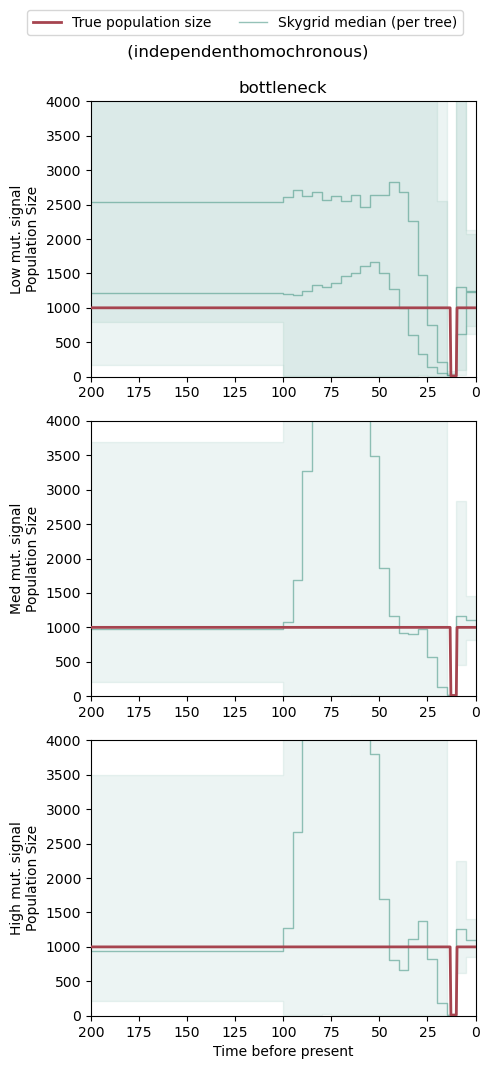

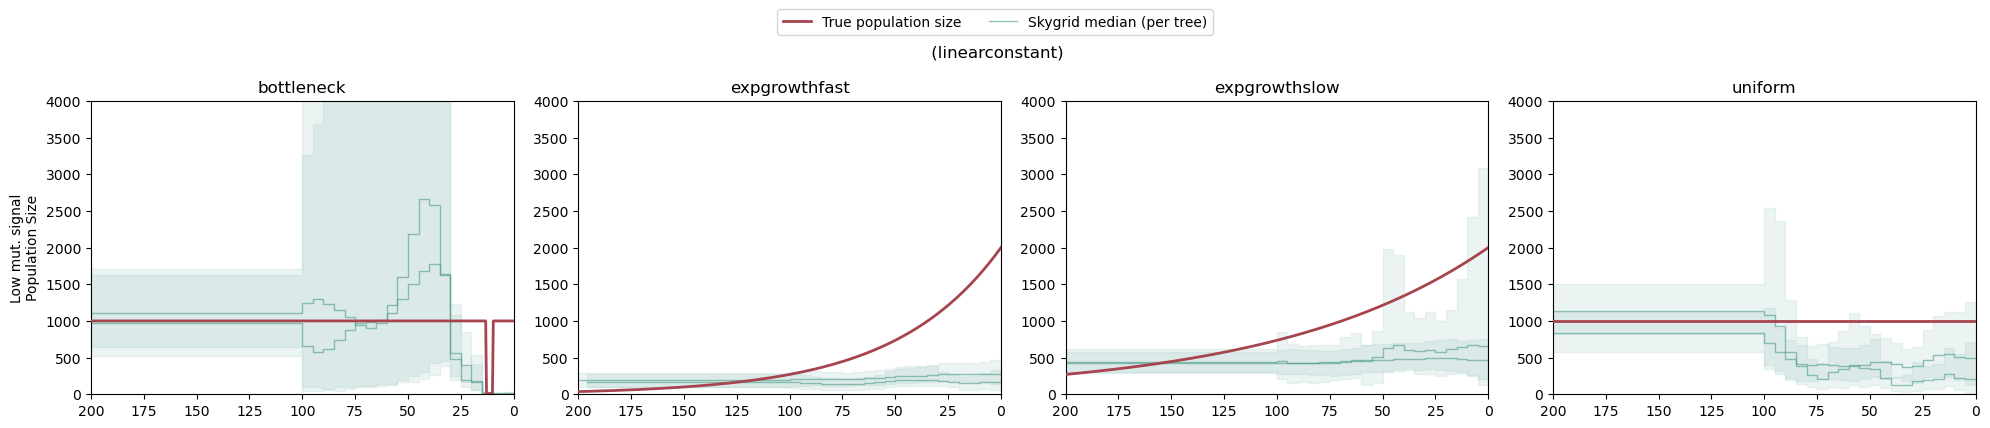

In [6]:
plot_skygrid_summary(skygrid_df, sampling="independenthomochronous", x_range=(0, 200), y_range=(0, 4000))
plot_skygrid_summary(skygrid_df, sampling="linearconstant", x_range=(0, 200), y_range=(0, 4000))